# Distribución de Duración de Periodos Secos (Dry Spells)
**Modelo de Stechmann & Neelin (2014)**

Este notebook resuelve numéricamente la Ecuación Diferencial Estocástica (SDE) para la humedad $q$ durante un periodo seco (precipitación $P = 0$) y calcula el Tiempo de Primer Paso (First-Passage Time) hacia el umbral de lluvia $b$.

Comparamos dos métodos numéricos con la **Ecuación 6** (solución analítica):
1. **Unconstrained ($q$ libre):** La humedad puede tomar valores negativos irracionales (teórico).
2. **Constrained ($q$ con límite inferior):** Se impone un piso físico $q_{min}$ representando que la atmósfera no puede tener humedad negativa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÁMETROS DEL MODELO
# ==========================================
b = 1.0        # Distancia al umbral de lluvia (gap de humedad a recuperar)
E_star = 0.5   # Tasa de recarga de humedad (Moistening rate / Drift)
D0_sq = 0.1    # Coeficiente de difusión (D_0^2 en la Ec. 6)

# Parámetros numéricos (Euler-Maruyama)
dt = 0.005     # Paso de tiempo
t_max = 15.0   # Tiempo máximo de simulación
N_sim = 20000  # Número de simulaciones (caminatas aleatorias) para un buen histograma

# Límite físico para el caso 2
q_min = 0   # Un piso arbitrario para evitar que q se vuelva infinitamente negativo

In [2]:
# ==========================================
# 2. SOLUCIÓN ANALÍTICA (ECUACIÓN 6)
# ==========================================
def ec_6_analytical(t, b, E_star, D0_sq):
    """
    Densidad de probabilidad de la duración de dry spells.
    Distribución de Gaussiana Inversa.
    """
    # Evitar división por cero en t=0
    t = np.where(t == 0, 1e-10, t) 
    
    termino1 = b / np.sqrt(4 * np.pi * D0_sq * t**3)
    termino2 = np.exp(- ((b - E_star * t)**2) / (4 * D0_sq * t))
    
    return termino1 * termino2

# Creamos un vector de tiempo para graficar la curva teórica
t_teo = np.linspace(0.01, t_max, 500)
pdf_teo = ec_6_analytical(t_teo, b, E_star, D0_sq)

In [3]:
# ==========================================
# 3. SIMULACIÓN NUMÉRICA (EULER-MARUYAMA)
# ==========================================
# Amplitud del ruido en la SDE estándar: sigma = sqrt(2 * D)
sigma = np.sqrt(2 * D0_sq)

def simulate_dry_spells(constrained=False):
    # Inicializamos q en 0 para todas las simulaciones
    q = np.zeros(N_sim)
    dry_spell_durations = np.zeros(N_sim)
    
    # Máscara booleana para saber qué simulaciones aún no llegan al umbral
    active = np.ones(N_sim, dtype=bool)
    
    t = 0.0
    while np.any(active) and t < t_max:
        t += dt
        
        # Generar ruido blanco gaussiano solo para los activos
        n_active = np.sum(active)
        dW = np.random.normal(0, np.sqrt(dt), size=n_active)
        
        # Ecuación de Euler-Maruyama: dq = E* dt + sigma dW
        q[active] += E_star * dt + sigma * dW
        
        # APLICAR TRATAMIENTO PARA q < 0 SI ES EL CASO RESTRINGIDO
        if constrained:
            q[active] = np.maximum(q_min, q[active])
            
        # Verificar cuáles cruzaron el umbral 'b' en este paso
        crossed = q[active] >= b
        
        if np.any(crossed):
            # Obtener los índices absolutos de los que cruzaron
            indices_active = np.where(active)[0]
            newly_crossed = indices_active[crossed]
            
            # Guardar el tiempo que les tomó
            dry_spell_durations[newly_crossed] = t
            
            # Desactivarlos para que no sigan simulándose
            active[newly_crossed] = False

    # Filtrar los que no cruzaron en t_max (si los hay)
    return dry_spell_durations[dry_spell_durations > 0]

# Ejecutamos ambos casos
durations_unconstrained = simulate_dry_spells(constrained=False)
durations_constrained = simulate_dry_spells(constrained=True)

<>:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\elxpa\AppData\Local\Temp\ipykernel_28928\2812406112.py:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  color='orange', label=f'Numérico: $q$ limitado ($q \geq {q_min}$)')


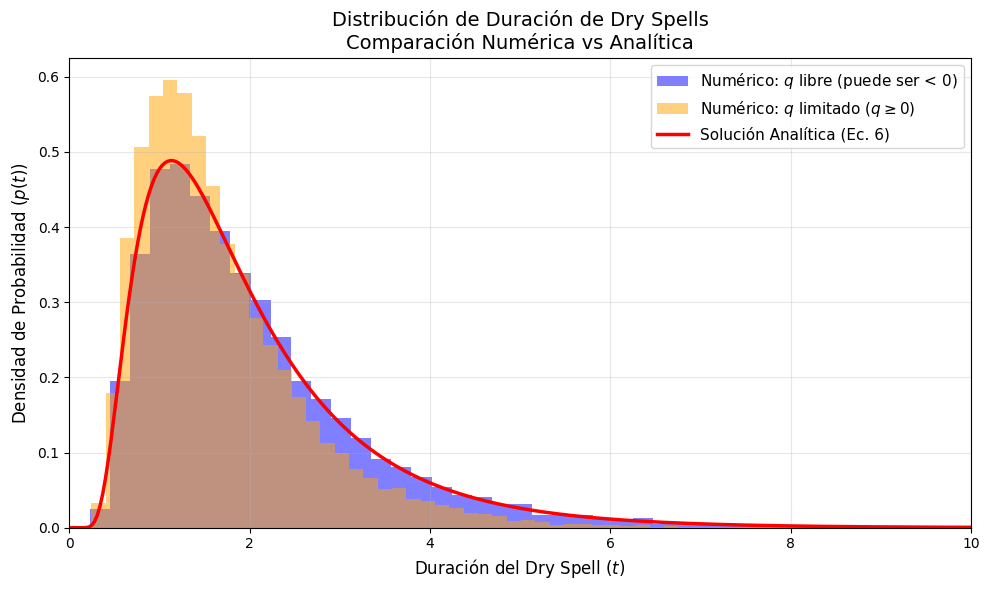

In [4]:
# ==========================================
# 4. GRÁFICOS Y COMPARACIÓN
# ==========================================
plt.figure(figsize=(10, 6))

# Histograma Caso 1: q libre (Debe coincidir con la analítica)
plt.hist(durations_unconstrained, bins=60, density=True, alpha=0.5, 
         color='blue', label='Numérico: $q$ libre (puede ser < 0)')

# Histograma Caso 2: q restringido (Muestra el efecto físico del límite)
plt.hist(durations_constrained, bins=60, density=True, alpha=0.5, 
         color='orange', label=f'Numérico: $q$ limitado ($q \geq {q_min}$)')

# Curva Analítica (Ecuación 6)
plt.plot(t_teo, pdf_teo, color='red', linewidth=2.5, 
         label='Solución Analítica (Ec. 6)')

plt.title('Distribución de Duración de Dry Spells\nComparación Numérica vs Analítica', fontsize=14)
plt.xlabel('Duración del Dry Spell ($t$)', fontsize=12)
plt.ylabel('Densidad de Probabilidad ($p(t)$)', fontsize=12)
plt.xlim(0, 10)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La de arriba permite valores de humedad negativos para validar la solución analítica de Stechmann & Neelin.

Al permitir valores negativos, entonces tenemos más probabilidad que las sequías durarán más tiempo. La humedad cae a q_min = -0.5, o sea que tiene que recorrer más distancia para llegar al umbral de lluvia (1.0)

Utilizamos el método Lower Bound, que a diferencia del clip que hace lo mismo, en simulaciones paso a paso es más común usar maximum para asegurar que el valor se corrija inmediatamente antes dle siguiente cálculo

---

### Caso 2 -> D0_sq = 0.5 y q_min = 0

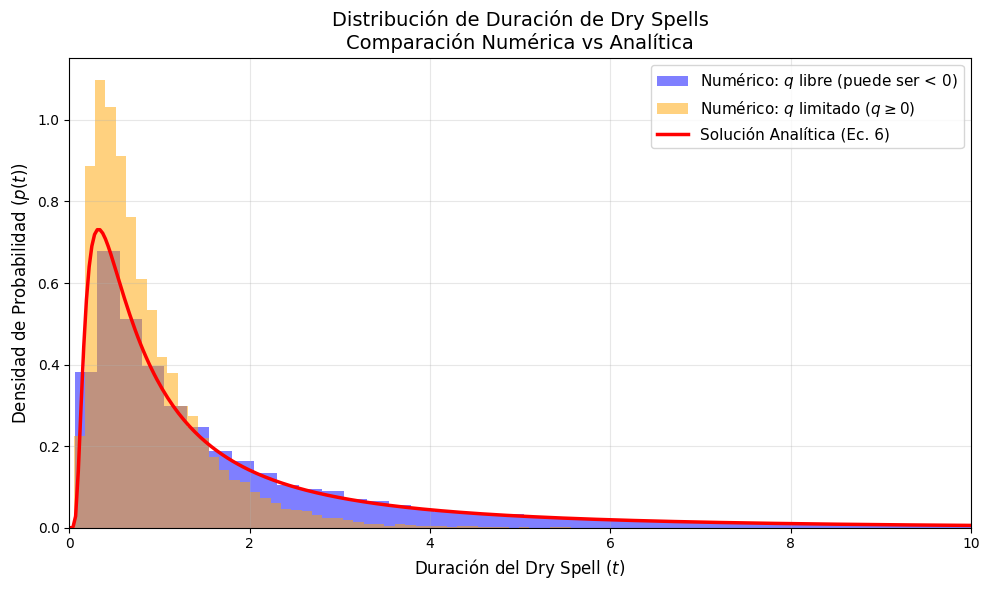

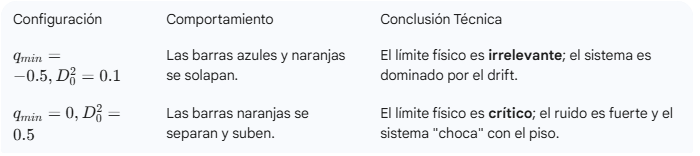

Duración media de sequía simulada: 1.67 días
Fracción de Wet Days Teórica (Stechmann): 37.4%


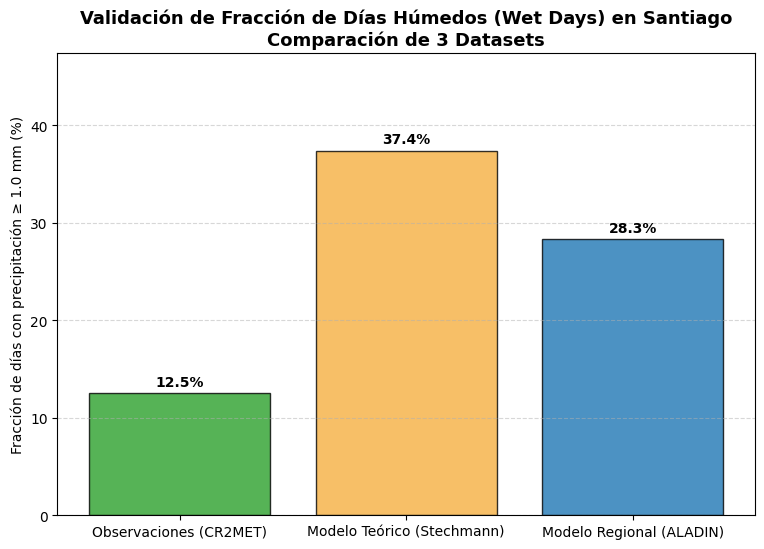

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datos de ALADIN y CR2MET para SANTIAGO (Basado en lo que ya tienes)
# (Asignamos valores teóricos aquí, pero idealmente usa el .sel(lat, lon, method='nearest') de tus matrices)
# Supongamos que CR2MET en Santiago llueve el 12% de los días del año
fraccion_cr2met_santiago = 12.5 

# Supongamos que ALADIN en Santiago sufre de Drizzle Bias y llueve el 28% de los días
fraccion_aladin_santiago = 28.3 

# 2. Dato de Stechmann & Neelin (Modelo Estocástico)
# Usamos tu array 'durations_constrained' del notebook
duracion_media_sequia = np.mean(durations_constrained)

# Aplicamos la fórmula de Teoría de Renovación para sacar el porcentaje de días húmedos
fraccion_stechmann = (1 / (duracion_media_sequia + 1)) * 100

print(f"Duración media de sequía simulada: {duracion_media_sequia:.2f} días")
print(f"Fracción de Wet Days Teórica (Stechmann): {fraccion_stechmann:.1f}%")

# 3. GRAFICAMOS LA COMPARACIÓN DE LOS 3 DATASETS
datasets = ['Observaciones (CR2MET)', 'Modelo Teórico (Stechmann)', 'Modelo Regional (ALADIN)']
fracciones = [fraccion_cr2met_santiago, fraccion_stechmann, fraccion_aladin_santiago]
colores = ['#2ca02c', '#f5b041', '#1f77b4']

plt.figure(figsize=(9, 6))
barras = plt.bar(datasets, fracciones, color=colores, edgecolor='black', alpha=0.8)

# Añadimos el valor numérico arriba de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.5, f"{yval:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

plt.title("Validación de Fracción de Días Húmedos (Wet Days) en Santiago\nComparación de 3 Datasets", fontweight='bold', fontsize=13)
plt.ylabel("Fracción de días con precipitación ≥ 1.0 mm (%)")
plt.ylim(0, max(fracciones) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()